# Sprint 3: From Market Data to Market Intelligence — Bariga LCDA

**GeoRAD Emerging Spatial Professionals Mentorship Program · Week 4**

This is my customized Sprint 3 notebook for the five **ward polygons** selected in Bariga LCDA. It is designed to stay consistent with my Sprint 2 workflow and `market_dataset.csv`.

### Study areas
1. Ibuowo / Owotutu
2. Ilaje
3. Pedro / Gbagada
4. Aiyetoro / Mafowoku
5. Owode / Orile Bariga

> **Important:** This analysis uses indicative current asking-price signals. It is not a formal property valuation and it does not predict future land prices.

## 0. Install packages

Run this once in a Google Colab session.

In [1]:
# ── Cell 0: Mount and navigate ────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/GEORAD_SPRINT_2')
print("📁 Working directory:", os.getcwd())

Mounted at /content/drive
📁 Working directory: /content/drive/MyDrive/GEORAD_SPRINT_2


In [2]:
%pip install -q pandas matplotlib geopandas folium mapclassify branca

## 1. Configuration

The names below are the five ward features used in the technical sprint. The notebook will validate that the GeoJSON and Sprint 2 market dataset contain the same five study areas.

In [3]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from branca.colormap import LinearColormap

EXPECTED_TOWNS = [
    "Ibuowo / Owotutu",
    "Ilaje",
    "Pedro / Gbagada",
    "Aiyetoro / Mafowoku",
    "Owode / Orile Bariga",
]

OUTPUT_DIR = Path("sprint3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def normalize_town_name(value):
    """Make town/ward names comparable without changing their meaning."""
    if pd.isna(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s*/\s*", " / ", text)
    return text

def parse_price(value):
    """Convert values such as '₦415000/sqm' to a numeric ₦/sqm value."""
    if value is None or pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    text = str(value).strip().replace(",", "")
    cleaned = re.sub(r"[^0-9.]", "", text)
    if not cleaned:
        return np.nan
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

def format_naira(value):
    return f"₦{value:,.0f}"

## 2. Load the Sprint 1/technical-sprint GeoJSON

Upload **`bariga_selected_wards.geojson`** — the five separate ward polygons.

The notebook deliberately uses `wardname`, because that is the field used by the actual Bariga GeoJSON and by the Sprint 2 notebook.

In [4]:
try:
    from google.colab import files
    print("Upload: bariga_selected_wards.geojson")
    uploaded_geo = files.upload()
    GEOJSON_PATH = Path(next(iter(uploaded_geo)))
except Exception:
    GEOJSON_PATH = Path("bariga_selected_wards.geojson")

gdf = gpd.read_file(GEOJSON_PATH)
print(f"Loaded: {GEOJSON_PATH}")
print(f"Features: {len(gdf)} | CRS: {gdf.crs}")
print("Geometry types:", gdf.geometry.geom_type.value_counts().to_dict())
print("Columns:", list(gdf.columns))

if "wardname" not in gdf.columns:
    raise ValueError(f"Expected 'wardname' in the GeoJSON. Found: {list(gdf.columns)}")

gdf = gdf.copy()
gdf["Town"] = gdf["wardname"].map(normalize_town_name)

expected_set = set(map(normalize_town_name, EXPECTED_TOWNS))
actual_set = set(gdf["Town"])
missing = sorted(expected_set - actual_set)
extra = sorted(actual_set - expected_set)

print("\nGeoJSON study areas:")
for town in gdf["Town"]:
    print(" -", town)

if missing or extra or len(gdf) != 5:
    raise ValueError(
        f"GeoJSON validation failed. Missing={missing}, Extra={extra}, Features={len(gdf)}. "
        "Check that the five selected ward polygons are being used."
    )

print("\n✓ GeoJSON contains exactly the five expected ward study areas.")

Upload: bariga_selected_wards.geojson


Saving bariga_selected_wards.geojson to bariga_selected_wards (1).geojson
Loaded: bariga_selected_wards (1).geojson
Features: 5 | CRS: EPSG:4326
Geometry types: {'MultiPolygon': 5}
Columns: ['FID', 'globalid', 'uniq_id', 'timestamp', 'editor', 'wardname', 'wardcode', 'lganame', 'lgacode', 'statename', 'statecode', 'amapcode', 'status', 'source', 'urban', 'geometry']

GeoJSON study areas:
 - Ibuowo / Owotutu
 - Ilaje
 - Pedro / Gbagada
 - Aiyetoro / Mafowoku
 - Owode / Orile Bariga

✓ GeoJSON contains exactly the five expected ward study areas.


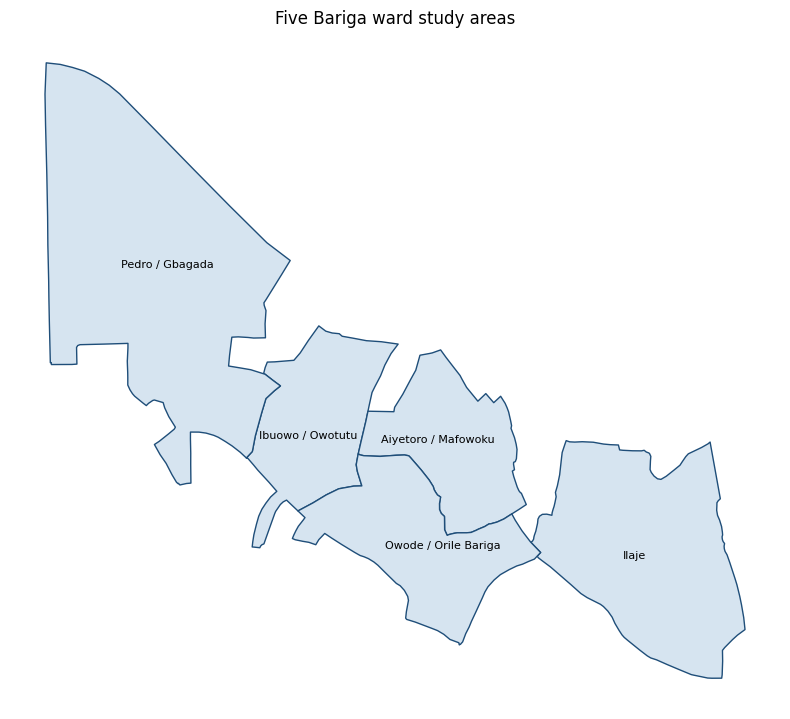

In [5]:
# Orientation map — before adding market data
fig, ax = plt.subplots(figsize=(8, 8))
gdf.to_crs(epsg=4326).plot(ax=ax, color="#d6e4f0", edgecolor="#1f4e79", linewidth=1)
for _, row in gdf.to_crs(epsg=4326).iterrows():
    pt = row.geometry.representative_point()
    ax.annotate(row["Town"], xy=(pt.x, pt.y), fontsize=8, ha="center")
ax.set_title("Five Bariga ward study areas")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "study_areas_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Load the Sprint 2 market dataset

The Sprint 2 dataset must contain at least:
- `Town`
- `Current Land Price/sqm`
- `Supporting Source`
- `Date Searched`

The values below are treated as **asking-price signals**, not confirmed transaction prices.

In [6]:
try:
    from google.colab import files
    print("Upload: market_dataset.csv")
    uploaded_csv = files.upload()
    DATA_PATH = Path(next(iter(uploaded_csv)))
except Exception:
    DATA_PATH = Path("market_dataset.csv")

raw_market = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Rows: {len(raw_market)}")
print("Columns:", list(raw_market.columns))
display(raw_market)

Upload: market_dataset.csv


Saving market_dataset.csv to market_dataset.csv
Loaded: market_dataset.csv
Rows: 5
Columns: ['Town', 'Current Land Price/sqm', 'Supporting Source', 'Date Searched']


,Town,Current Land Price/sqm,Supporting Source,Date Searched
0,Ibuowo / Owotutu,₦415000/sqm,"Land for Sale in Shomolu, Lagos - Nigeria Prop...",2026-09-26
1,Ilaje,₦320000/sqm,"Land for Sale in Bariga, Shomolu, Lagos | http...",2026-09-26
2,Pedro / Gbagada,₦1200000/sqm,FOR SALE | DIRECT SALES A prime 725sqm parcel ...,2026-09-26
3,Aiyetoro / Mafowoku,₦420000/sqm,"Land for Sale in Shomolu, Lagos | https://nige...",2026-09-26
4,Owode / Orile Bariga,₦250000/sqm,"Residential Land for Sale in Bariga, Shomolu, ...",2026-09-26


In [7]:
# Validate and standardize the Sprint 2 dataset
required_columns = ["Town", "Current Land Price/sqm", "Supporting Source", "Date Searched"]
missing_columns = [c for c in required_columns if c not in raw_market.columns]
if missing_columns:
    raise ValueError(f"Missing required Sprint 2 columns: {missing_columns}")

market_df = raw_market.copy()
market_df["Town"] = market_df["Town"].map(normalize_town_name)
market_df["Price_sqm"] = market_df["Current Land Price/sqm"].map(parse_price)

# Basic quality checks
print("Missing values by required field:")
print(market_df[required_columns].isna().sum())

if market_df["Price_sqm"].isna().any():
    raise ValueError("At least one market price could not be converted to a numeric ₦/sqm value.")

if (market_df["Price_sqm"] <= 0).any():
    raise ValueError("All market prices must be greater than zero.")

expected_set = set(map(normalize_town_name, EXPECTED_TOWNS))
market_set = set(market_df["Town"])
missing_towns = sorted(expected_set - market_set)
extra_towns = sorted(market_set - expected_set)

print("\nTown-name comparison:")
print("Missing from market dataset:", missing_towns or "None")
print("Extra in market dataset:", extra_towns or "None")

if missing_towns or extra_towns:
    raise ValueError("Market dataset does not match the five selected ward study areas.")

# Sprint 2 should have one market signal per selected ward.
counts = market_df.groupby("Town").size()
print("\nRows per study area:")
print(counts)
if not (counts == 1).all():
    raise ValueError(
        "This customized notebook expects exactly one Sprint 2 price signal per ward. "
        "If you intentionally add multiple observations per ward, update the aggregation logic first."
    )

print("\n✓ Sprint 2 market dataset passed validation.")

Missing values by required field:
Town                      0
Current Land Price/sqm    0
Supporting Source         0
Date Searched             0
dtype: int64

Town-name comparison:
Missing from market dataset: None
Extra in market dataset: None

Rows per study area:
Town
Aiyetoro / Mafowoku     1
Ibuowo / Owotutu        1
Ilaje                   1
Owode / Orile Bariga    1
Pedro / Gbagada         1
dtype: int64

✓ Sprint 2 market dataset passed validation.


## 4. Inspect the Sprint 2 prices before analysis

Because each ward has one Sprint 2 price, the **Indicative Market Level for each ward is that same price**.

We still inspect the five values together because one unusually high or low observation can affect the overall picture.

In [8]:
summary = market_df[["Town", "Price_sqm"]].copy()
summary["Indicative Market Level (₦/sqm)"] = summary["Price_sqm"]
summary["Price Display"] = summary["Price_sqm"].map(lambda x: f"{format_naira(x)} / sqm")
summary = summary.sort_values("Price_sqm", ascending=False).reset_index(drop=True)
display(summary)

prices = market_df["Price_sqm"]
print("Overall mean:", format_naira(prices.mean()), "/sqm")
print("Overall median:", format_naira(prices.median()), "/sqm")
print("Minimum:", format_naira(prices.min()), "/sqm")
print("Maximum:", format_naira(prices.max()), "/sqm")
print("Maximum/minimum ratio:", round(prices.max() / prices.min(), 2), "x")

,Town,Price_sqm,Indicative Market Level (₦/sqm),Price Display
0,Pedro / Gbagada,1200000.0,1200000.0,"₦1,200,000 / sqm"
1,Aiyetoro / Mafowoku,420000.0,420000.0,"₦420,000 / sqm"
2,Ibuowo / Owotutu,415000.0,415000.0,"₦415,000 / sqm"
3,Ilaje,320000.0,320000.0,"₦320,000 / sqm"
4,Owode / Orile Bariga,250000.0,250000.0,"₦250,000 / sqm"


Overall mean: ₦521,000 /sqm
Overall median: ₦415,000 /sqm
Minimum: ₦250,000 /sqm
Maximum: ₦1,200,000 /sqm
Maximum/minimum ratio: 4.8 x


In [9]:
# Simple statistical check for an unusual value (IQR rule).
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

market_df["IQR Outlier Flag"] = (market_df["Price_sqm"] < lower_fence) | (market_df["Price_sqm"] > upper_fence)

print(f"Q1: {format_naira(q1)} /sqm")
print(f"Q3: {format_naira(q3)} /sqm")
print(f"IQR: {format_naira(iqr)} /sqm")
print(f"Lower fence: {format_naira(lower_fence)} /sqm")
print(f"Upper fence: {format_naira(upper_fence)} /sqm")

flags = market_df.loc[market_df["IQR Outlier Flag"], ["Town", "Price_sqm"]]
if len(flags):
    print("\nStatistical flag(s) — investigate, but do not automatically delete:")
    display(flags)
else:
    print("\nNo IQR outliers detected.")

print("\nInterpretation note: an outlier flag is a statistical signal, not proof that the market value is wrong. Property characteristics, road access, title, plot size and listing conditions can produce genuine local differences.")

Q1: ₦320,000 /sqm
Q3: ₦420,000 /sqm
IQR: ₦100,000 /sqm
Lower fence: ₦170,000 /sqm
Upper fence: ₦570,000 /sqm

Statistical flag(s) — investigate, but do not automatically delete:


,Town,Price_sqm
2,Pedro / Gbagada,1200000.0



Interpretation note: an outlier flag is a statistical signal, not proof that the market value is wrong. Property characteristics, road access, title, plot size and listing conditions can produce genuine local differences.


## 5. Create the market-intelligence table

The final table keeps the Sprint 2 evidence fields and adds the analysis fields.

With **n = 1** for each ward, the mean and median for that ward are necessarily the same as the Sprint 2 price.

In [10]:
intelligence_df = market_df[
    ["Town", "Current Land Price/sqm", "Supporting Source", "Date Searched", "Price_sqm", "IQR Outlier Flag"]
].copy()

intelligence_df["Indicative Market Level (₦/sqm)"] = intelligence_df["Price_sqm"]
intelligence_df["Indicative Market Level"] = intelligence_df["Price_sqm"].map(lambda x: f"{format_naira(x)} / sqm")
intelligence_df["Observations (n)"] = 1

intelligence_df = intelligence_df.sort_values("Indicative Market Level (₦/sqm)", ascending=False).reset_index(drop=True)

print("Market intelligence table:")
display(intelligence_df)

print("\nImportant: these are indicative asking-price signals from the Sprint 2 dataset, not formal valuations.")

Market intelligence table:


,Town,Current Land Price/sqm,Supporting Source,Date Searched,Price_sqm,IQR Outlier Flag,Indicative Market Level (₦/sqm),Indicative Market Level,Observations (n)
0,Pedro / Gbagada,₦1200000/sqm,FOR SALE | DIRECT SALES A prime 725sqm parcel ...,2026-09-26,1200000.0,True,1200000.0,"₦1,200,000 / sqm",1
1,Aiyetoro / Mafowoku,₦420000/sqm,"Land for Sale in Shomolu, Lagos | https://nige...",2026-09-26,420000.0,False,420000.0,"₦420,000 / sqm",1
2,Ibuowo / Owotutu,₦415000/sqm,"Land for Sale in Shomolu, Lagos - Nigeria Prop...",2026-09-26,415000.0,False,415000.0,"₦415,000 / sqm",1
3,Ilaje,₦320000/sqm,"Land for Sale in Bariga, Shomolu, Lagos | http...",2026-09-26,320000.0,False,320000.0,"₦320,000 / sqm",1
4,Owode / Orile Bariga,₦250000/sqm,"Residential Land for Sale in Bariga, Shomolu, ...",2026-09-26,250000.0,False,250000.0,"₦250,000 / sqm",1



Important: these are indicative asking-price signals from the Sprint 2 dataset, not formal valuations.


## 6. Compare the five study areas

Use the values to describe similarities and differences. Do not turn the price differences into a claim about future land prices or property value.

In [11]:
comparison = intelligence_df[["Town", "Indicative Market Level (₦/sqm)", "IQR Outlier Flag"]].copy()
comparison = comparison.rename(columns={"Indicative Market Level (₦/sqm)": "Indicative Market Level"})
comparison["Difference from overall median (₦/sqm)"] = comparison["Indicative Market Level"].map(lambda x: x - prices.median())
comparison["Difference from overall median (%)"] = comparison["Indicative Market Level"].map(lambda x: ((x / prices.median()) - 1) * 100)
comparison = comparison.sort_values("Indicative Market Level", ascending=False)
display(comparison)

print("\nObservation prompts:")
print("• Which wards have relatively similar asking-price signals?")
print("• Which ward is visibly different from the others?")
print("• What local factors could be investigated to explain the difference?")
print("• Does the unusually high/low value have supporting listing evidence?")
print("• Remember: one observation per ward is not enough to establish a stable market average.")

,Town,Indicative Market Level,IQR Outlier Flag,Difference from overall median (₦/sqm),Difference from overall median (%)
0,Pedro / Gbagada,1200000.0,True,785000.0,189.156627
1,Aiyetoro / Mafowoku,420000.0,False,5000.0,1.204819
2,Ibuowo / Owotutu,415000.0,False,0.0,0.000000
3,Ilaje,320000.0,False,-95000.0,-22.891566
4,Owode / Orile Bariga,250000.0,False,-165000.0,-39.759036



Observation prompts:
• Which wards have relatively similar asking-price signals?
• Which ward is visibly different from the others?
• What local factors could be investigated to explain the difference?
• Does the unusually high/low value have supporting listing evidence?
• Remember: one observation per ward is not enough to establish a stable market average.


## 7. Visualize the indicative market levels

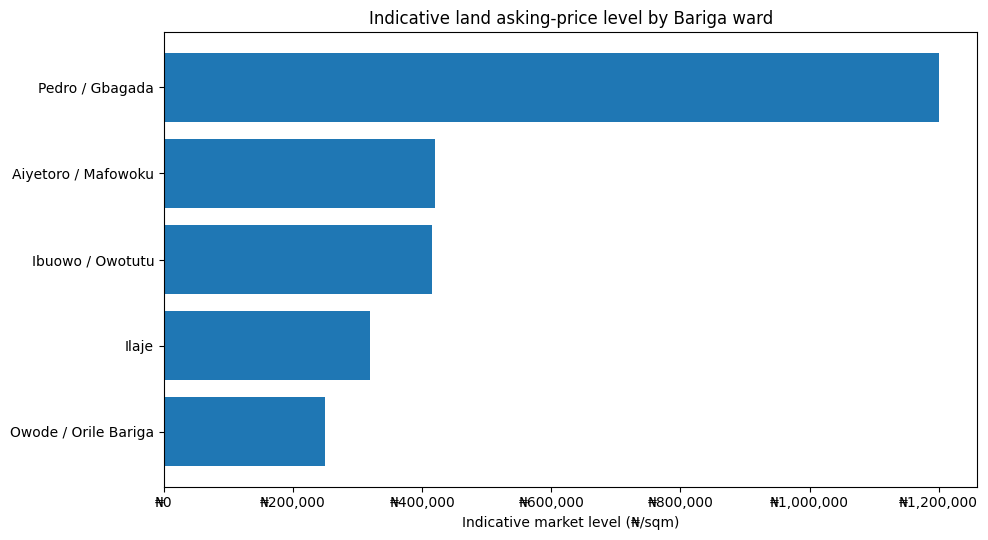

Saved: sprint3_outputs/indicative_market_levels.png


In [12]:
plot_df = intelligence_df.sort_values("Indicative Market Level (₦/sqm)")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot_df["Town"], plot_df["Indicative Market Level (₦/sqm)"])
ax.set_xlabel("Indicative market level (₦/sqm)")
ax.set_title("Indicative land asking-price level by Bariga ward")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₦{int(x):,}"))
plt.tight_layout()
chart_path = OUTPUT_DIR / "indicative_market_levels.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", chart_path)

## 8. Join the market signal back to the ward polygons

The join is done using the normalized `Town` name. Before mapping, the notebook checks that all five polygons received a market value.

In [13]:
map_table = intelligence_df[["Town", "Indicative Market Level (₦/sqm)", "Indicative Market Level", "Observations (n)"]].copy()
mapped = gdf.merge(map_table, on="Town", how="left", validate="one_to_one")

unmatched = mapped[mapped["Indicative Market Level (₦/sqm)"].isna()]["Town"].tolist()
print(f"Matched polygons: {mapped['Indicative Market Level (₦/sqm)'].notna().sum()} / {len(mapped)}")
print("Unmatched polygons:", unmatched or "None")

if unmatched:
    raise ValueError("One or more ward polygons did not receive a market value. Fix the town-name matching before using the map.")

mapped_wgs = mapped.to_crs(epsg=4326) if mapped.crs and mapped.crs.to_epsg() != 4326 else mapped.copy()
if mapped_wgs.crs is None:
    mapped_wgs = mapped_wgs.set_crs(epsg=4326)

minx, miny, maxx, maxy = mapped_wgs.total_bounds
center = [(miny + maxy) / 2, (minx + maxx) / 2]

BASEMAP_TILES = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}"
BASEMAP_ATTR = "Tiles &copy; Esri"

m = folium.Map(location=center, zoom_start=12, tiles=BASEMAP_TILES, attr=BASEMAP_ATTR)

vmin = float(mapped_wgs["Indicative Market Level (₦/sqm)"].min())
vmax = float(mapped_wgs["Indicative Market Level (₦/sqm)"].max())
if vmin == vmax:
    vmax = vmin + 1

colormap = LinearColormap(
    colors=["#f7fbff", "#6baed6", "#08306b"],
    vmin=vmin,
    vmax=vmax,
    caption="Indicative market level (₦/sqm)",
)

def style_feature(feature):
    value = feature["properties"].get("Indicative Market Level (₦/sqm)")
    if value is None:
        return {"fillColor": "#cccccc", "color": "#666666", "weight": 1, "fillOpacity": 0.4}
    return {
        "fillColor": colormap(float(value)),
        "color": "#1f4e79",
        "weight": 1.5,
        "fillOpacity": 0.65,
    }

folium.GeoJson(
    json.loads(mapped_wgs.to_json()),
    style_function=style_feature,
    tooltip=folium.GeoJsonTooltip(
        fields=["Town", "Indicative Market Level"],
        aliases=["Ward", "Indicative market level"],
    ),
    popup=folium.GeoJsonPopup(
        fields=["Town", "Indicative Market Level", "Observations (n)"],
        aliases=["Ward", "Indicative market level", "Observations"],
    ),
).add_to(m)
colormap.add_to(m)
m.fit_bounds([[miny, minx], [maxy, maxx]])

map_path = OUTPUT_DIR / "bariga_market_intelligence_map.html"
m.save(map_path)
print("Saved:", map_path)
m

Matched polygons: 5 / 5
Unmatched polygons: None
Saved: sprint3_outputs/bariga_market_intelligence_map.html


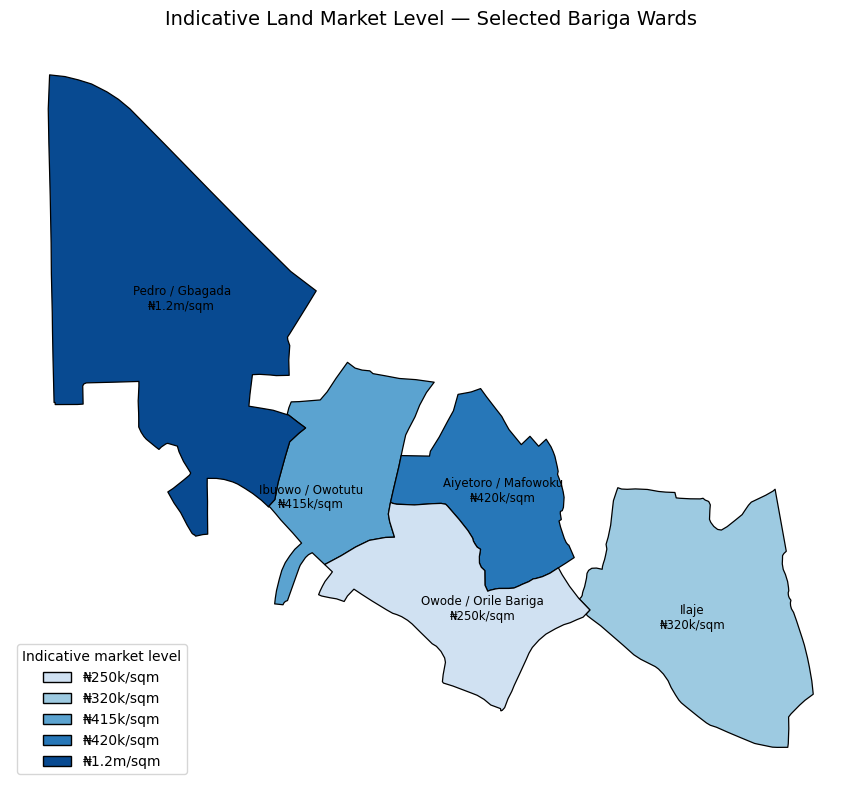

Saved: sprint3_outputs/bariga_market_intelligence_map.png


In [14]:
# Static market-intelligence map for the submission/README
# The labels include the indicative price so the map can be understood without the colour scale.
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 8))

# Five ordered classes based on the actual five observed values.
ordered_values = sorted(mapped_wgs["Indicative Market Level (₦/sqm)"].unique())
blues = plt.cm.Blues(np.linspace(0.20, 0.90, len(ordered_values)))
cmap = ListedColormap(blues)
if len(ordered_values) > 1:
    boundaries = ordered_values + [ordered_values[-1] + 1]
    norm = BoundaryNorm(boundaries, cmap.N)
else:
    norm = None

mapped_wgs.plot(
    ax=ax,
    column="Indicative Market Level (₦/sqm)",
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.9,
)

label_offsets = {
    "Ibuowo / Owotutu": (-18, -8),
    "Aiyetoro / Mafowoku": (18, 0),
    "Pedro / Gbagada": (0, 0),
    "Ilaje": (0, 0),
    "Owode / Orile Bariga": (0, -2),
}

for _, row in mapped_wgs.iterrows():
    pt = row.geometry.representative_point()
    value = float(row["Indicative Market Level (₦/sqm)"])
    short_price = f"₦{value/1_000_000:.1f}m/sqm" if value >= 1_000_000 else f"₦{value/1000:.0f}k/sqm"
    label = f"{row['Town']}\n{short_price}"
    dx, dy = label_offsets.get(row["Town"], (0, 0))
    ax.annotate(
        label,
        xy=(pt.x, pt.y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8.5,
        ha="center",
        va="center",
    )

legend_handles = [
    Patch(facecolor=cmap(i), edgecolor="black", label=(f"₦{v/1_000_000:.1f}m/sqm" if v >= 1_000_000 else f"₦{v/1000:.0f}k/sqm"))
    for i, v in enumerate(ordered_values)
]
ax.legend(handles=legend_handles, title="Indicative market level", loc="lower left", frameon=True)
ax.set_title("Indicative Land Market Level — Selected Bariga Wards", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
static_map_path = OUTPUT_DIR / "bariga_market_intelligence_map.png"
fig.savefig(static_map_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", static_map_path)

## 9. Required experiment — price sensitivity

Because each ward has only one Sprint 2 observation, comparing a ward's mean and median does not tell us much: they are identical when n = 1.

Instead, this experiment changes **only Pedro / Gbagada by +10% as a hypothetical scenario** and checks how the overall mean changes. This does **not** claim that Pedro's real market price increased; it only demonstrates how a single high observation can influence a small dataset.

In [15]:
experiment_df = market_df[["Town", "Price_sqm"]].copy()
base_mean = experiment_df["Price_sqm"].mean()
base_median = experiment_df["Price_sqm"].median()

TARGET_TOWN = "Pedro / Gbagada"
mask = experiment_df["Town"] == TARGET_TOWN
if mask.sum() != 1:
    raise ValueError(f"Expected exactly one Pedro / Gbagada row; found {mask.sum()}")

original_price = float(experiment_df.loc[mask, "Price_sqm"].iloc[0])
experiment_df.loc[mask, "Price_sqm"] = original_price * 1.10
experiment_mean = experiment_df["Price_sqm"].mean()
experiment_median = experiment_df["Price_sqm"].median()

print("Base overall mean:", format_naira(base_mean), "/sqm")
print("Base overall median:", format_naira(base_median), "/sqm")
print("Hypothetical Pedro price (+10%):", format_naira(original_price * 1.10), "/sqm")
print("Experiment overall mean:", format_naira(experiment_mean), "/sqm")
print("Experiment overall median:", format_naira(experiment_median), "/sqm")
print("Change in overall mean:", format_naira(experiment_mean - base_mean), "/sqm")

print("\nObservation: changing one observation affects the overall mean, while the median may remain unchanged when the middle-ranked observations are unchanged. This shows why both measures are useful when inspecting a small dataset.")

Base overall mean: ₦521,000 /sqm
Base overall median: ₦415,000 /sqm
Hypothetical Pedro price (+10%): ₦1,320,000 /sqm
Experiment overall mean: ₦545,000 /sqm
Experiment overall median: ₦415,000 /sqm
Change in overall mean: ₦24,000 /sqm

Observation: changing one observation affects the overall mean, while the median may remain unchanged when the middle-ranked observations are unchanged. This shows why both measures are useful when inspecting a small dataset.


In [16]:
# Save the experiment result so Task 6 is documented as an output.
experiment_result = pd.DataFrame({
    "Scenario": ["Base dataset", "Hypothetical Pedro / Gbagada +10%"],
    "Pedro / Gbagada price (₦/sqm)": [original_price, original_price * 1.10],
    "Overall mean (₦/sqm)": [base_mean, experiment_mean],
    "Overall median (₦/sqm)": [base_median, experiment_median],
})
experiment_result.to_csv(OUTPUT_DIR / "experiment_sensitivity.csv", index=False, encoding="utf-8-sig")
display(experiment_result)
print("Saved:", OUTPUT_DIR / "experiment_sensitivity.csv")

,Scenario,Pedro / Gbagada price (₦/sqm),Overall mean (₦/sqm),Overall median (₦/sqm)
0,Base dataset,1200000.0,521000.0,415000.0
1,Hypothetical Pedro / Gbagada +10%,1320000.0,545000.0,415000.0


Saved: sprint3_outputs/experiment_sensitivity.csv


## 10. Export the Sprint 3 market-intelligence dataset

The exported table keeps the Sprint 2 evidence fields and adds the derived market-intelligence fields.

In [17]:
export_columns = [
    "Town",
    "Current Land Price/sqm",
    "Supporting Source",
    "Date Searched",
    "Indicative Market Level (₦/sqm)",
    "Indicative Market Level",
    "Observations (n)",
    "IQR Outlier Flag",
]

submission = intelligence_df[export_columns].copy()
submission.to_csv(OUTPUT_DIR / "market_intelligence.csv", index=False, encoding="utf-8-sig")
submission.to_json(OUTPUT_DIR / "market_intelligence.json", orient="records", force_ascii=False, indent=2)

# Also save a small comparison table for analysis notes.
comparison.to_csv(OUTPUT_DIR / "market_comparison.csv", index=False, encoding="utf-8-sig")

print("Created:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p)

try:
    from google.colab import files
    files.download(str(OUTPUT_DIR / "market_intelligence.csv"))
    files.download(str(OUTPUT_DIR / "market_intelligence.json"))
    files.download(str(OUTPUT_DIR / "indicative_market_levels.png"))
    files.download(str(OUTPUT_DIR / "bariga_market_intelligence_map.png"))
    files.download(str(OUTPUT_DIR / "experiment_sensitivity.csv"))
except Exception:
    print("Not running in Colab download mode; files remain in sprint3_outputs/.")

Created:
 - sprint3_outputs/bariga_market_intelligence_map.html
 - sprint3_outputs/bariga_market_intelligence_map.png
 - sprint3_outputs/experiment_sensitivity.csv
 - sprint3_outputs/indicative_market_levels.png
 - sprint3_outputs/market_comparison.csv
 - sprint3_outputs/market_intelligence.csv
 - sprint3_outputs/market_intelligence.json
 - sprint3_outputs/study_areas_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Analyst notes for the Sprint 3 submission

The five observed asking-price signals range from **₦250,000/sqm to ₦1,200,000/sqm**. Ibuowo / Owotutu (₦415,000/sqm) and Aiyetoro / Mafowoku (₦420,000/sqm) are close to each other, while Ilaje and Owode / Orile Bariga have lower observed signals. Pedro / Gbagada is substantially higher than the other four observations and is flagged by the IQR rule for further validation.

The Sprint 2 source material also contained evidence that asking prices in the Pedro / Gbagada area can vary substantially by micro-location, accessibility, title and property characteristics. Therefore, the outlier flag is treated as a reason to investigate the observation, not as evidence that the value is wrong.

Because there is only **one market observation per ward**, these values should be interpreted as **indicative asking-price signals**, not stable market averages or formal valuations. The analysis also does not establish a causal relationship between price and physical development; the development-change signal belongs to the later satellite-imagery stage of the overall project.

## 12. Final analyst checklist

Before submission, confirm:

- [ ] Five separate Bariga ward polygons are mapped.
- [ ] The market dataset contains the same five ward names.
- [ ] All five prices are present and expressed as ₦/sqm.
- [ ] Supporting sources and search dates are retained.
- [ ] Indicative Market Level equals the single Sprint 2 price for each ward because n = 1.
- [ ] Pedro / Gbagada's high value was inspected rather than silently removed.
- [ ] A comparison chart and static map were produced.
- [ ] Market levels were successfully joined back to all five polygons.
- [ ] The Task 6 sensitivity experiment is saved as `experiment_sensitivity.csv`.
- [ ] The final output is described as indicative asking-price intelligence, not formal valuation or future-price prediction.